In [1]:
install.packages("pls")
install.packages("plsVarSel")
install.packages("Metrics")
install.packages("ggplot2")


Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [1]:
# --- ライブラリ読み込み ---
library(pls)
library(plsVarSel)
library(Metrics)

# --- データ読み込み・前処理 ---
ifname <- "n-base-noSMILES.csv"
readData <- read.delim(ifname, header=TRUE, sep=",", row.names=1, as.is=TRUE)
readData2 <- readData[, !sapply(readData, is.character)]

# --- 計算対象の目的変数 ---
target_y_list <- c("Jsc", "Voc", "FF", "PCEmax")

# --- 除外する列名 ---
rmlist <- c("Jsc", "Voc", "FF", "PCEmax", "PCEcal", "PCEdiff", "PCEave")

# --- 各目的変数について処理 ---
for (yname in target_y_list) {
  cat("\n=============================\n")
  cat("Target:", yname, "\n")
  cat("=============================\n")

  Y <- readData2[, yname]
  Xnames <- setdiff(colnames(readData2), rmlist)
  X <- readData2[, Xnames]
  
  # 欠損のある列を除去
  Nadata <- is.na(X)
  NNa <- colSums(Nadata)
  XX <- X[, NNa == 0]

  # 欠損行除去
  dMerge <- data.frame(Y, XX)
  Nadata <- na.omit(dMerge)

  # 標準偏差チェックとスケーリング
  sdcheck <- apply(Nadata, 2, sd)
  TF <- sdcheck != 0
  ssd <- scale(Nadata[, TF])
  ssd[, 1] <- Nadata[, 1]  # Yは非スケーリングで戻す
  YXdata <- data.frame(ssd)

  # --- PLS モデル構築 ---
  set.seed(123)
  result1.pls <- plsr(Y ~ ., data=YXdata, scale=FALSE, validation="CV", segments=10)
  plspress <- result1.pls$validation$PRESS
  ncomponent <- which.min(plspress)
  Ypred1 <- result1.pls$validation$pred[,,ncomponent]

  # --- Q2 の計算と表示 ---
  tss <- sum((YXdata[,1] - mean(YXdata[,1]))^2)
  Q2 <- 1 - plspress / tss
  mc <- which.max(Q2)
  corCV <- cor(YXdata[,1], Ypred1)

  par(cex=1.0)
  barplot(Q2[1:20], names.arg=1:20)
  titleR <- paste0(yname, ": # of comps = ", mc,
                   " Q2= ", substring(max(Q2),1,5),
                   " corCV= ", substring(corCV,1,5))
  par(mar=c(5,5,5,5))
  plot(YXdata[,1], Ypred1, xlab="original", ylab="prediction", main=titleR)

  # --- モデルからの予測値と R2・RMSE の表示 ---
  Ypred2 <- predict(result1.pls, newdata=YXdata, ncomp=ncomponent)
  rss <- sum((YXdata[,1] - Ypred2)^2)
  R2 <- 1 - rss / tss
  CR <- cor(YXdata[,1], Ypred2)
  RMSEval <- rmse(YXdata[,1], Ypred2)

  cat("R2      =", round(R2, 4), "\n")
  cat("corALL  =", round(CR, 4), "\n")
  cat("RMSE    =", round(RMSEval, 4), "\n")

  titleR2 <- paste0(yname, ": R2= ", substring(R2,1,5),
                    " corALL= ", substring(CR,1,5),
                    " RMSE= ", round(RMSEval, 3))
  plot(YXdata[,1], Ypred2, xlab="original", ylab="prediction", main=titleR2)

  # --- 回帰係数の表示（数値） ---
  coefs <- coefficients(result1.pls, ncomp=ncomponent)[,1,1]
  sorted_coefs <- sort(coefs, decreasing=TRUE)
  cat("\n[回帰係数ランキング]\n")
  print(round(sorted_coefs, 5))

  # --- 回帰係数の棒グラフ ---
  par(cex=0.5)
  par(mar=c(5,20,1,1))
  barplot(sorted_coefs, horiz=TRUE, las=1)
  abline(v=0, lty=1)
}



Attaching package: 'pls'


The following object is masked from 'package:stats':

    loadings


Registered S3 method overwritten by 'plsVarSel':
  method       from
  print.mvrVal pls 

Warning message in file(file, "rt"):
"cannot open file 'n_base.csv': No such file or directory"


ERROR: Error in file(file, "rt"): cannot open the connection


Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done




Target: Jsc 


Warning message:
"Removed 13 rows containing missing values or values outside the scale range
(`geom_bar()`)."


R2      = 0.2933 
corALL  = 0.5416 
RMSE    = 4.2475 


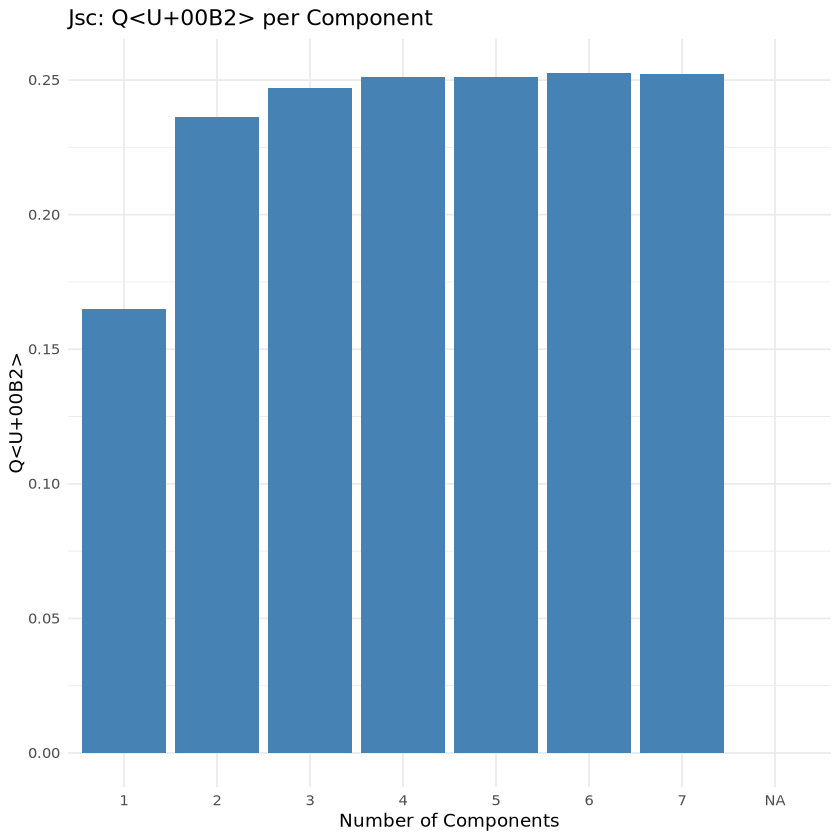


[<U+56DE><U+5E30><U+4FC2><U+6570><U+30E9><U+30F3><U+30AD><U+30F3><U+30B0>]
   MnkDap1M    Egoptp1M Mmonomerp1M     LUMOp1M      PDIp1M     HOMOp1M 
    3.51960     1.13014     0.70347     0.62841     0.37164    -0.39663 
   MwkDap1M 
   -1.68202 

Target: Voc 


Warning message:
"Removed 13 rows containing missing values or values outside the scale range
(`geom_bar()`)."


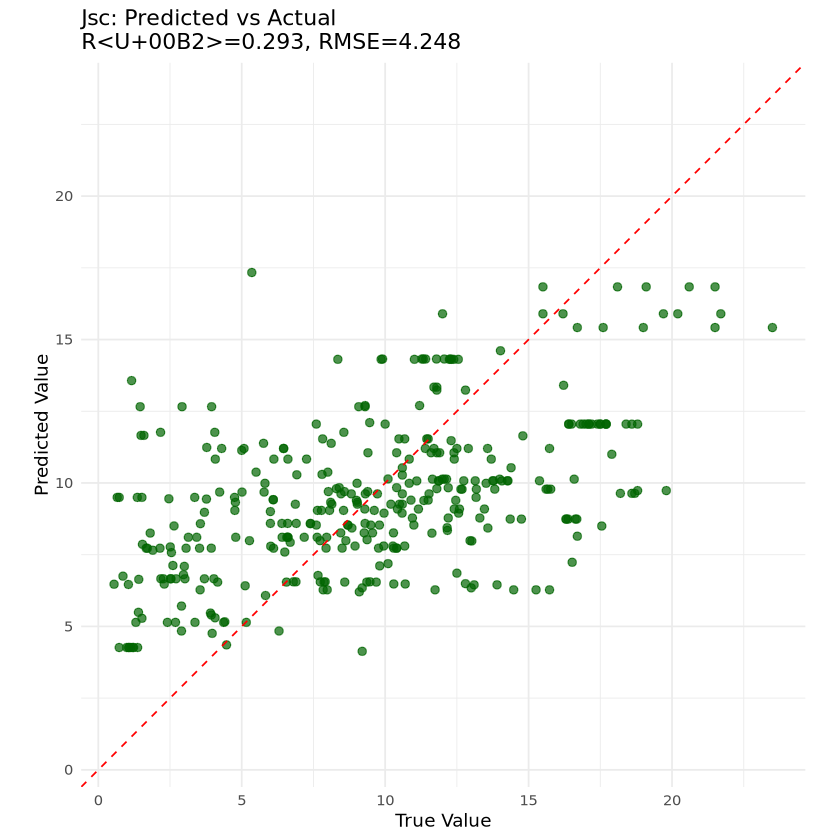

R2      = 0.7158 
corALL  = 0.846 
RMSE    = 0.0807 


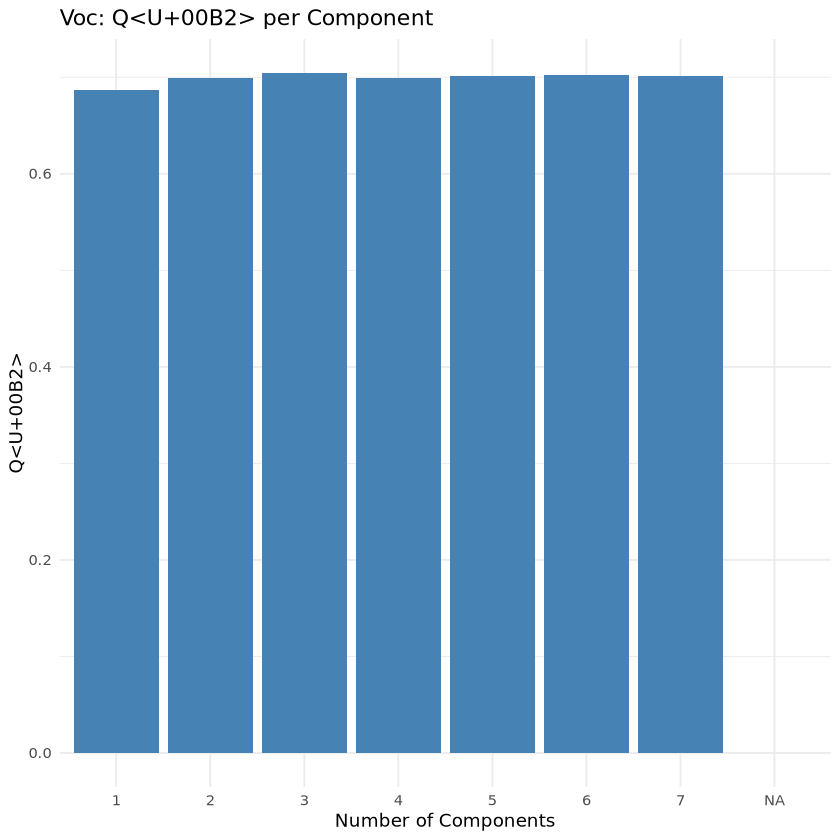


[<U+56DE><U+5E30><U+4FC2><U+6570><U+30E9><U+30F3><U+30AD><U+30F3><U+30B0>]
   Egoptp1M     HOMOp1M Mmonomerp1M    MwkDap1M    MnkDap1M     LUMOp1M 
    0.08287     0.06159     0.02758     0.00944     0.00307    -0.00370 
     PDIp1M 
   -0.00931 

Target: FF 


Warning message:
"Removed 13 rows containing missing values or values outside the scale range
(`geom_bar()`)."


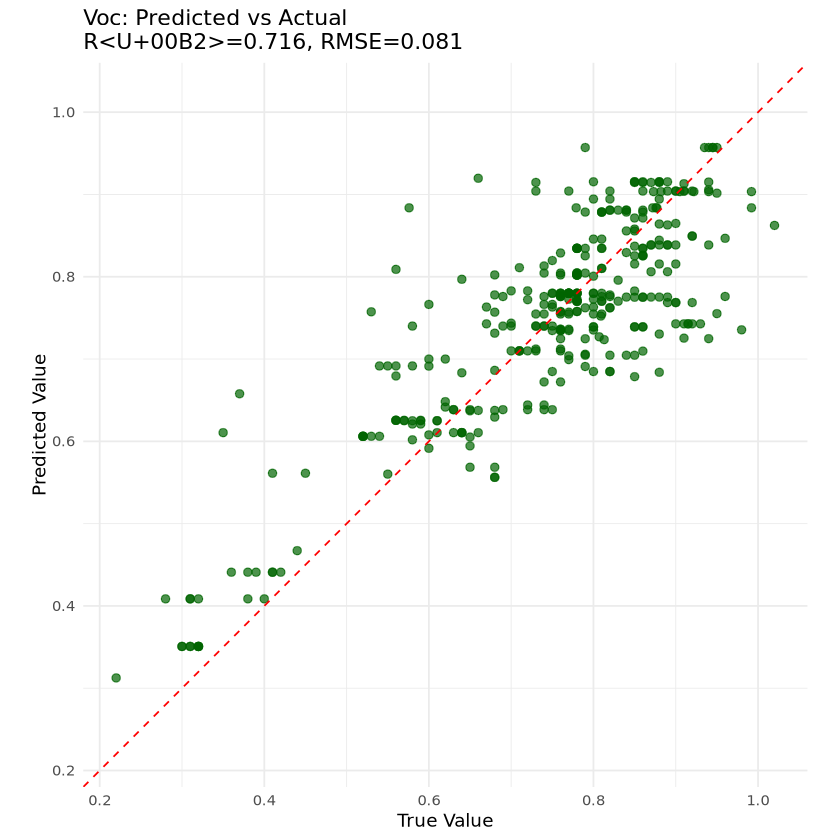

R2      = 0.1757 
corALL  = 0.4192 
RMSE    = 0.1011 


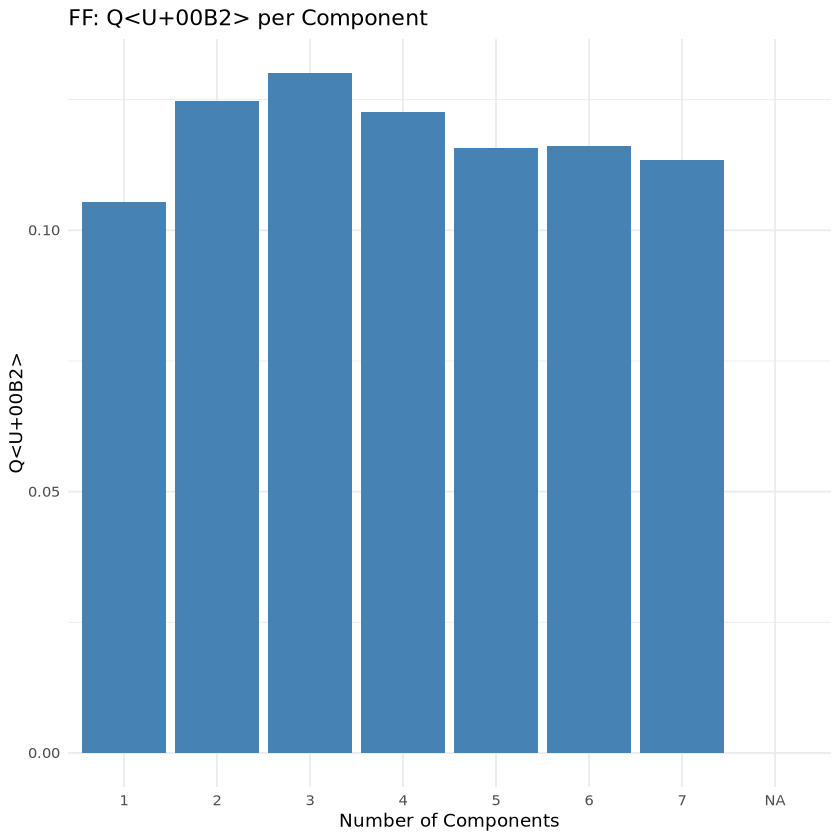


[<U+56DE><U+5E30><U+4FC2><U+6570><U+30E9><U+30F3><U+30AD><U+30F3><U+30B0>]
   MnkDap1M    Egoptp1M Mmonomerp1M     HOMOp1M     LUMOp1M    MwkDap1M 
    0.03730     0.02196     0.01937     0.00781     0.00604     0.00274 
     PDIp1M 
   -0.01483 

Target: PCEmax 


Warning message:
"Removed 13 rows containing missing values or values outside the scale range
(`geom_bar()`)."


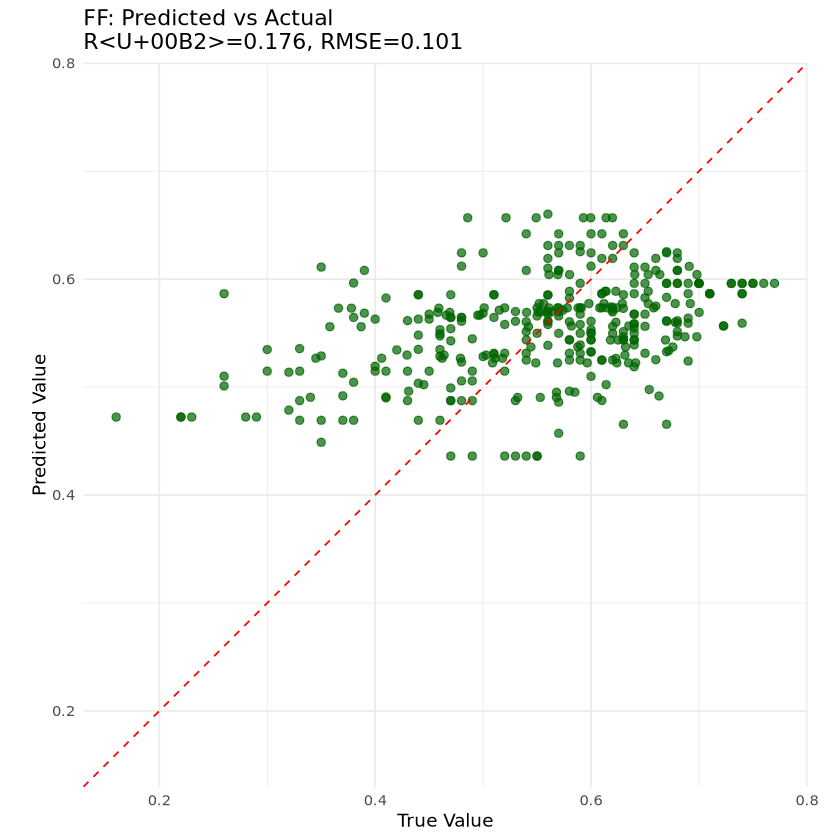

R2      = 0.2696 
corALL  = 0.5192 
RMSE    = 2.2562 


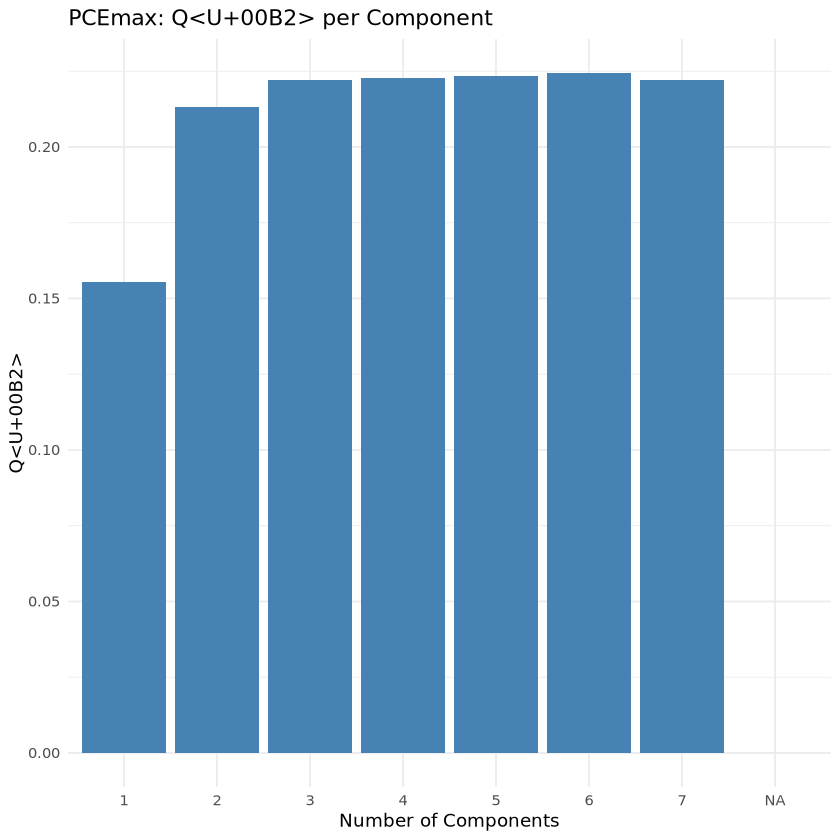


[<U+56DE><U+5E30><U+4FC2><U+6570><U+30E9><U+30F3><U+30AD><U+30F3><U+30B0>]
   MnkDap1M    Egoptp1M     LUMOp1M Mmonomerp1M      PDIp1M     HOMOp1M 
    1.52339     0.98317     0.48752     0.41048     0.15474    -0.17314 
   MwkDap1M 
   -0.70869 


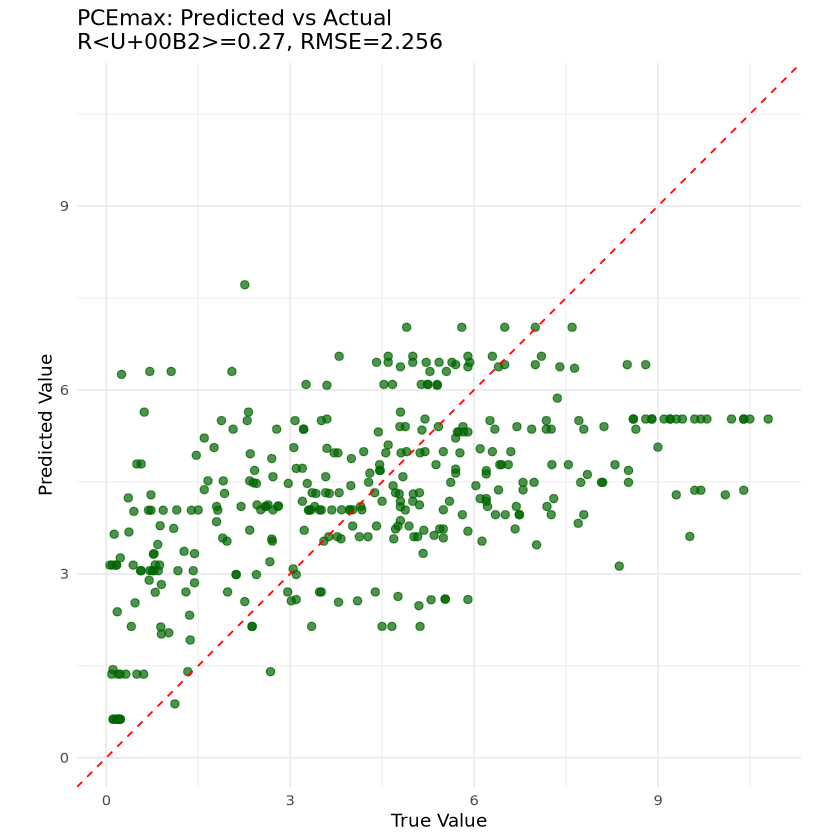

In [8]:
install.packages("pls")
install.packages("plsVarSel")
install.packages("Metrics")
install.packages("ggplot2")

library(pls)
library(plsVarSel)
library(Metrics)
library(ggplot2)

ifname <- "n-base-noSMILES.csv"
readData <- read.delim(ifname, header=TRUE, sep=",", row.names=1, as.is=TRUE)
readData2 <- readData[, !sapply(readData, is.character)]

target_y_list <- c("Jsc", "Voc", "FF", "PCEmax")
rmlist <- c("Jsc", "Voc", "FF", "PCEmax", "PCEcal", "PCEdiff", "PCEave")

for (yname in target_y_list) {
  cat("\n=============================\n")
  cat("Target:", yname, "\n")
  cat("=============================\n")

  Y <- readData2[, yname]
  Xnames <- setdiff(colnames(readData2), rmlist)
  X <- readData2[, Xnames]

  Nadata <- is.na(X)
  NNa <- colSums(Nadata)
  XX <- X[, NNa == 0]

  dMerge <- data.frame(Y, XX)
  Nadata <- na.omit(dMerge)

  sdcheck <- apply(Nadata, 2, sd)
  TF <- sdcheck != 0
  ssd <- scale(Nadata[, TF])
  ssd[, 1] <- Nadata[, 1]
  YXdata <- data.frame(ssd)

  set.seed(123)
  result1.pls <- plsr(Y ~ ., data=YXdata, scale=FALSE, validation="CV", segments=10)
  plspress <- result1.pls$validation$PRESS
  ncomponent <- which.min(plspress)
  Ypred1 <- result1.pls$validation$pred[,,ncomponent]

  tss <- sum((YXdata[,1] - mean(YXdata[,1]))^2)
  Q2 <- 1 - plspress / tss
  corCV <- cor(YXdata[,1], Ypred1)

  # === ggplot: Q2バー ===
  df_q2 <- data.frame(Component = seq_along(Q2), Q2 = as.numeric(Q2))
    df_q2 <- na.omit(df_q2)
    print(
      ggplot(df_q2[1:20, ], aes(x = factor(Component), y = Q2)) +
        geom_bar(stat = "identity", fill = "steelblue") +
        labs(title = paste0(yname, ": Q² per Component"),
             x = "Number of Components", y = "Q²") +
        theme_minimal()
        # coord_fixed() は **不要**（棒グラフが潰れるため）
    )

  # === R2などの計算 ===
  Ypred2 <- predict(result1.pls, newdata=YXdata, ncomp=ncomponent)
  rss <- sum((YXdata[,1] - Ypred2)^2)
  R2 <- 1 - rss / tss
  CR <- cor(YXdata[,1], Ypred2)
  RMSEval <- rmse(YXdata[,1], Ypred2)

  cat("R2      =", round(R2, 4), "\n")
  cat("corALL  =", round(CR, 4), "\n")
  cat("RMSE    =", round(RMSEval, 4), "\n")

  # === ggplot: 予測 vs 実測 ===
  df_pred <- data.frame(True = YXdata[,1], Predicted = as.vector(Ypred2))
    lims <- range(c(df_pred$True, df_pred$Predicted), na.rm = TRUE)


    print(
      ggplot(df_pred, aes(x = True, y = Predicted)) +
        geom_point(color = "darkgreen", alpha = 0.7, size = 2) +
        geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "red") +
        labs(title = paste0(yname, ": Predicted vs Actual\nR²=", round(R2, 3),
                            ", RMSE=", round(RMSEval, 3)),
             x = "True Value", y = "Predicted Value") +
        coord_fixed(ratio = 1, xlim = lims, ylim = lims) +  # <- 明示的にスケール固定
        theme_minimal()
    )

  # === 回帰係数の出力 ===
  coefs <- coefficients(result1.pls, ncomp=ncomponent)[,1,1]
  sorted_coefs <- sort(coefs, decreasing=TRUE)
  cat("\n[回帰係数ランキング]\n")
  print(round(sorted_coefs, 5))
}


Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done




Target: Jsc 


Warning message:
"Removed 13 rows containing missing values or values outside the scale range
(`geom_bar()`)."


R2      = 0.2933 
corALL  = 0.5416 
RMSE    = 4.2475 
MAE     = 3.4357 
RPD     = 1.191 


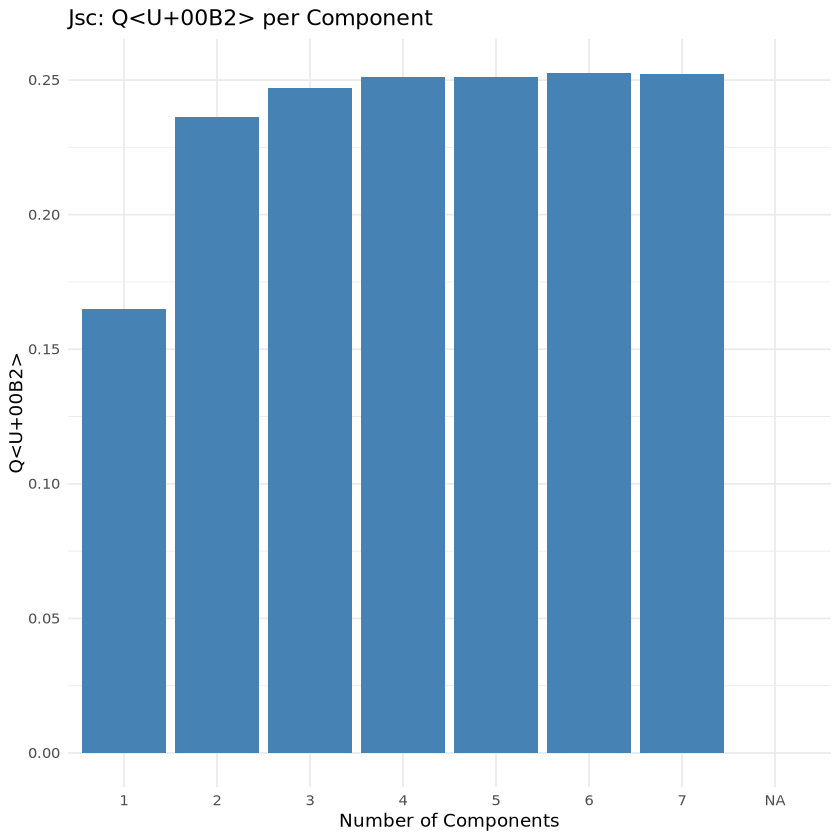


[<U+56DE><U+5E30><U+4FC2><U+6570><U+30E9><U+30F3><U+30AD><U+30F3><U+30B0>]
   MnkDap1M    Egoptp1M Mmonomerp1M     LUMOp1M      PDIp1M     HOMOp1M 
    3.51960     1.13014     0.70347     0.62841     0.37164    -0.39663 
   MwkDap1M 
   -1.68202 


ERROR: Error in vip(result1.pls, ncomp = ncomponent): could not find function "vip"


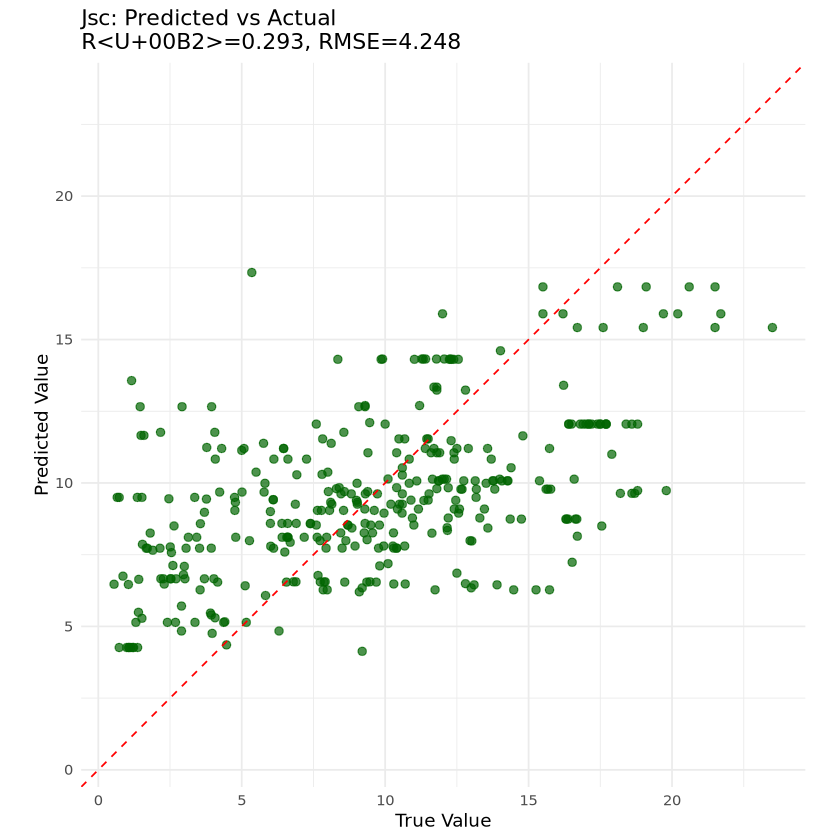

In [9]:
# 必要なパッケージ
install.packages("pls")
install.packages("plsVarSel")
install.packages("Metrics")
install.packages("ggplot2")

# ライブラリ読み込み
library(pls)
library(plsVarSel)
library(Metrics)
library(ggplot2)

# データ読み込み
ifname <- "n-base-noSMILES.csv"
readData <- read.delim(ifname, header=TRUE, sep=",", row.names=1, as.is=TRUE)
readData2 <- readData[, !sapply(readData, is.character)]

target_y_list <- c("Jsc", "Voc", "FF", "PCEmax")
rmlist <- c("Jsc", "Voc", "FF", "PCEmax", "PCEcal", "PCEdiff", "PCEave")

for (yname in target_y_list) {
  cat("\n=============================\n")
  cat("Target:", yname, "\n")
  cat("=============================\n")

  Y <- readData2[, yname]
  Xnames <- setdiff(colnames(readData2), rmlist)
  X <- readData2[, Xnames]

  Nadata <- is.na(X)
  NNa <- colSums(Nadata)
  XX <- X[, NNa == 0]

  dMerge <- data.frame(Y, XX)
  Nadata <- na.omit(dMerge)

  sdcheck <- apply(Nadata, 2, sd)
  TF <- sdcheck != 0
  ssd <- scale(Nadata[, TF])
  ssd[, 1] <- Nadata[, 1]
  YXdata <- data.frame(ssd)

  set.seed(123)
  result1.pls <- plsr(Y ~ ., data=YXdata, scale=FALSE, validation="CV", segments=10)
  plspress <- result1.pls$validation$PRESS
  ncomponent <- which.min(plspress)
  Ypred1 <- result1.pls$validation$pred[,,ncomponent]

  tss <- sum((YXdata[,1] - mean(YXdata[,1]))^2)
  Q2 <- 1 - plspress / tss
  corCV <- cor(YXdata[,1], Ypred1)

  # === ggplot: Q2バー ===
  df_q2 <- na.omit(data.frame(Component = seq_along(Q2), Q2 = as.numeric(Q2)))
  print(
    ggplot(df_q2[1:20, ], aes(x = factor(Component), y = Q2)) +
      geom_bar(stat = "identity", fill = "steelblue") +
      labs(title = paste0(yname, ": Q² per Component"),
           x = "Number of Components", y = "Q²") +
      theme_minimal()
  )

  # === R2などの計算 ===
  Ypred2 <- predict(result1.pls, newdata=YXdata, ncomp=ncomponent)
  rss <- sum((YXdata[,1] - Ypred2)^2)
  R2 <- 1 - rss / tss
  CR <- cor(YXdata[,1], Ypred2)
  RMSEval <- rmse(YXdata[,1], Ypred2)
  MAEval <- mae(YXdata[,1], Ypred2)
  sd_Y <- sd(YXdata[,1])
  RPDval <- sd_Y / RMSEval

  cat("R2      =", round(R2, 4), "\n")
  cat("corALL  =", round(CR, 4), "\n")
  cat("RMSE    =", round(RMSEval, 4), "\n")
  cat("MAE     =", round(MAEval, 4), "\n")
  cat("RPD     =", round(RPDval, 3), "\n")

  # === ggplot: 予測 vs 実測 ===
  df_pred <- data.frame(True = YXdata[,1], Predicted = as.vector(Ypred2))
  lims <- range(c(df_pred$True, df_pred$Predicted), na.rm = TRUE)
  print(
    ggplot(df_pred, aes(x = True, y = Predicted)) +
      geom_point(color = "darkgreen", alpha = 0.7, size = 2) +
      geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "red") +
      labs(title = paste0(yname, ": Predicted vs Actual\nR²=", round(R2, 3),
                          ", RMSE=", round(RMSEval, 3)),
           x = "True Value", y = "Predicted Value") +
      coord_fixed(ratio = 1, xlim = lims, ylim = lims) +
      theme_minimal()
  )

  # === 回帰係数の出力 ===
  coefs <- coefficients(result1.pls, ncomp=ncomponent)[,1,1]
  sorted_coefs <- sort(coefs, decreasing=TRUE)
  cat("\n[回帰係数ランキング]\n")
  print(round(sorted_coefs, 5))

  # === VIPスコアの出力 ===
    vip_scores <- plsVarSel::vippls(result1.pls, ncomp = ncomponent)
    vip_sorted <- sort(vip_scores, decreasing = TRUE)
    cat("\n[VIPスコア上位変数]\n")
    print(round(vip_sorted[1:10], 3))


  # === PRESSプロット ===
  press_df <- data.frame(Component = seq_along(plspress), PRESS = as.numeric(plspress))
  print(
    ggplot(press_df, aes(x = Component, y = PRESS)) +
      geom_line(color = "tomato") +
      geom_point() +
      theme_minimal() +
      labs(title = paste0(yname, ": PRESS per Component"),
           x = "Number of Components", y = "PRESS")
  )
}


In [14]:
# === VIPスコア手計算関数 ===
calc_vip <- function(pls_model, ncomp) {
  SS <- pls_model$Yloadings[1:ncomp, , drop = FALSE]^2
  W <- pls_model$loading.weights[, 1:ncomp, drop = FALSE]
  p <- nrow(W)
  t <- pls_model$scores[, 1:ncomp, drop = FALSE]

  Wnorm2 <- colSums(W^2)
  SSY <- sum(SS)
  
  vip_scores <- numeric(p)
  for (j in 1:p) {
    weight <- 0
    for (a in 1:ncomp) {
      weight <- weight + SS[a] * (W[j, a]^2 / Wnorm2[a])
    }
    vip_scores[j] <- sqrt(p * weight / SSY)
  }
  names(vip_scores) <- rownames(W)
  return(vip_scores)
}



Target: Jsc 
R2      = 0.2933 
corALL  = 0.5416 
RMSE    = 4.2475 
MAE     = 3.4357 
RPD     = 1.191 


Warning message:
"Removed 13 rows containing missing values or values outside the scale range
(`geom_bar()`)."


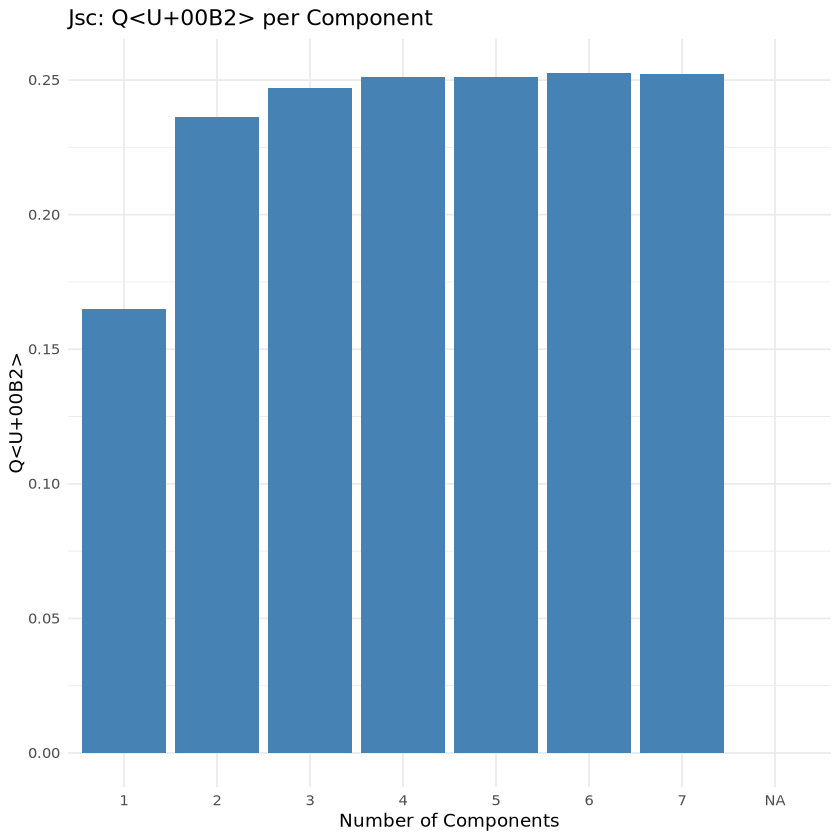


[<U+56DE><U+5E30><U+4FC2><U+6570><U+30E9><U+30F3><U+30AD><U+30F3><U+30B0>]
   MnkDap1M    Egoptp1M Mmonomerp1M     LUMOp1M      PDIp1M     HOMOp1M 
    3.51960     1.13014     0.70347     0.62841     0.37164    -0.39663 
   MwkDap1M 
   -1.68202 


ERROR: Error in pls_model$Yloadings[1:ncomp, , drop = FALSE]: subscript out of bounds


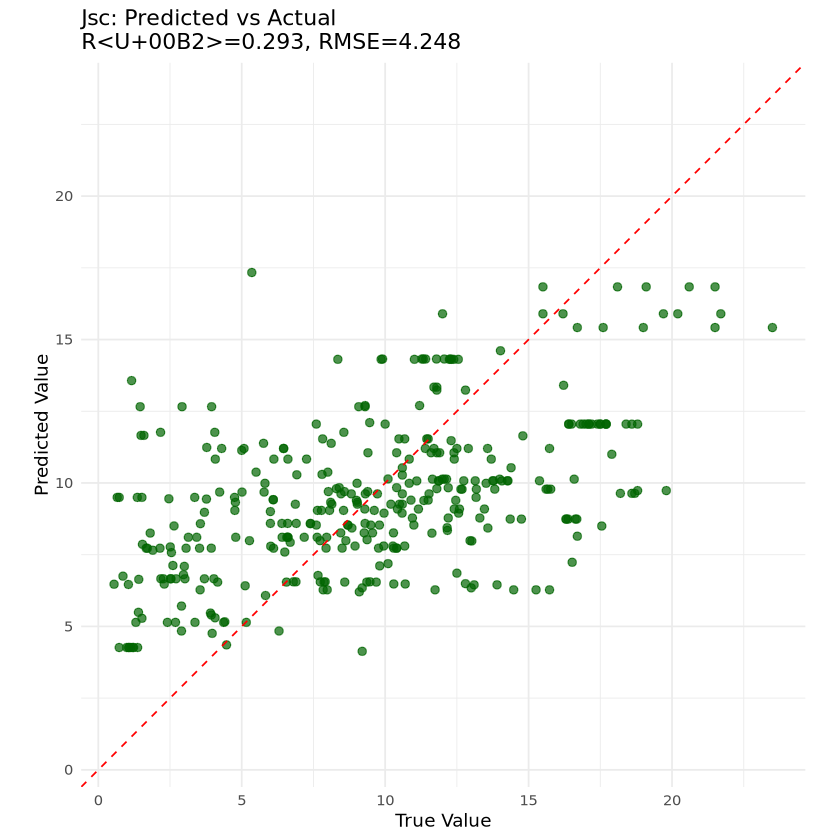

In [15]:
library(pls)
library(plsVarSel)
library(Metrics)
library(ggplot2)

# --- データ読み込み ---
ifname <- "n-base-noSMILES.csv"
readData <- read.delim(ifname, header=TRUE, sep=",", row.names=1, as.is=TRUE)
readData2 <- readData[, !sapply(readData, is.character)]

target_y_list <- c("Jsc", "Voc", "FF", "PCEmax")
rmlist <- c("Jsc", "Voc", "FF", "PCEmax", "PCEcal", "PCEdiff", "PCEave")

for (yname in target_y_list) {
  cat("\n=============================\n")
  cat("Target:", yname, "\n")
  cat("=============================\n")

  Y <- readData2[, yname]
  Xnames <- setdiff(colnames(readData2), rmlist)
  X <- readData2[, Xnames]

  # 欠損列除去
  Nadata <- is.na(X)
  NNa <- colSums(Nadata)
  XX <- X[, NNa == 0]

  # 欠損行除去＋標準化
  dMerge <- data.frame(Y, XX)
  Nadata <- na.omit(dMerge)
  sdcheck <- apply(Nadata, 2, sd)
  TF <- sdcheck != 0
  ssd <- scale(Nadata[, TF])
  ssd[, 1] <- Nadata[, 1]
  YXdata <- data.frame(ssd)

  # --- PLSモデリング ---
  set.seed(123)
  result1.pls <- plsr(Y ~ ., data=YXdata, scale=FALSE, validation="CV", segments=10)
  plspress <- result1.pls$validation$PRESS
  ncomponent <- which.min(plspress)
  Ypred1 <- result1.pls$validation$pred[,,ncomponent]

  # --- Q2とR2などの指標計算 ---
  tss <- sum((YXdata[,1] - mean(YXdata[,1]))^2)
  Q2 <- 1 - plspress / tss
  corCV <- cor(YXdata[,1], Ypred1)

  Ypred2 <- predict(result1.pls, newdata=YXdata, ncomp=ncomponent)
  rss <- sum((YXdata[,1] - Ypred2)^2)
  R2 <- 1 - rss / tss
  CR <- cor(YXdata[,1], Ypred2)
  RMSEval <- rmse(YXdata[,1], Ypred2)
  MAEval <- mae(YXdata[,1], Ypred2)
  sd_Y <- sd(YXdata[,1])
  RPDval <- sd_Y / RMSEval

  cat("R2      =", round(R2, 4), "\n")
  cat("corALL  =", round(CR, 4), "\n")
  cat("RMSE    =", round(RMSEval, 4), "\n")
  cat("MAE     =", round(MAEval, 4), "\n")
  cat("RPD     =", round(RPDval, 3), "\n")

  # --- Q²バープロット ---
  df_q2 <- na.omit(data.frame(Component = seq_along(Q2), Q2 = as.numeric(Q2)))
  print(
    ggplot(df_q2[1:20, ], aes(x = factor(Component), y = Q2)) +
      geom_bar(stat = "identity", fill = "steelblue") +
      labs(title = paste0(yname, ": Q² per Component"),
           x = "Number of Components", y = "Q²") +
      theme_minimal()
  )

  # --- 予測 vs 実測 プロット ---
  df_pred <- data.frame(True = YXdata[,1], Predicted = as.vector(Ypred2))
  lims <- range(c(df_pred$True, df_pred$Predicted), na.rm = TRUE)
  print(
    ggplot(df_pred, aes(x = True, y = Predicted)) +
      geom_point(color = "darkgreen", alpha = 0.7, size = 2) +
      geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "red") +
      labs(title = paste0(yname, ": Predicted vs Actual\nR²=", round(R2, 3),
                          ", RMSE=", round(RMSEval, 3)),
           x = "True Value", y = "Predicted Value") +
      coord_fixed(ratio = 1, xlim = lims, ylim = lims) +
      theme_minimal()
  )

  # --- 回帰係数表示 ---
  coefs <- coefficients(result1.pls, ncomp=ncomponent)[,1,1]
  sorted_coefs <- sort(coefs, decreasing=TRUE)
  cat("\n[回帰係数ランキング]\n")
  print(round(sorted_coefs, 5))

  # --- VIPスコア数値＋棒グラフ ---
# --- VIPスコア数値＋棒グラフ ---
# --- VIPスコア計算（自作関数） ---
vip_scores <- calc_vip(result1.pls, ncomponent)
vip_sorted <- sort(vip_scores, decreasing = TRUE)

cat("\n[VIPスコア上位変数]\n")
print(round(vip_sorted[1:10], 3))

# --- VIPプロット ---
df_vip <- data.frame(Variable = names(vip_sorted[1:10]), VIP = vip_sorted[1:10])
df_vip$Variable <- factor(df_vip$Variable, levels = rev(df_vip$Variable))

print(
  ggplot(df_vip, aes(x = Variable, y = VIP)) +
    geom_bar(stat = "identity", fill = "darkorange") +
    coord_flip() +
    labs(title = paste0(yname, ": Top 10 VIP Scores")) +
    theme_minimal()
)



  # --- PRESS per Component プロット ---
  press_df <- data.frame(Component = seq_along(plspress), PRESS = as.numeric(plspress))
  print(
    ggplot(press_df, aes(x = Component, y = PRESS)) +
      geom_line(color = "tomato") +
      geom_point() +
      theme_minimal() +
      labs(title = paste0(yname, ": PRESS per Component"),
           x = "Number of Components", y = "PRESS")
  )
}



Target: Jsc 
R2      = 0.2933 
corALL  = 0.5416 
RMSE    = 4.2475 
MAE     = 3.4357 
RPD     = 1.191 


Warning message:
"Removed 13 rows containing missing values or values outside the scale range
(`geom_bar()`)."


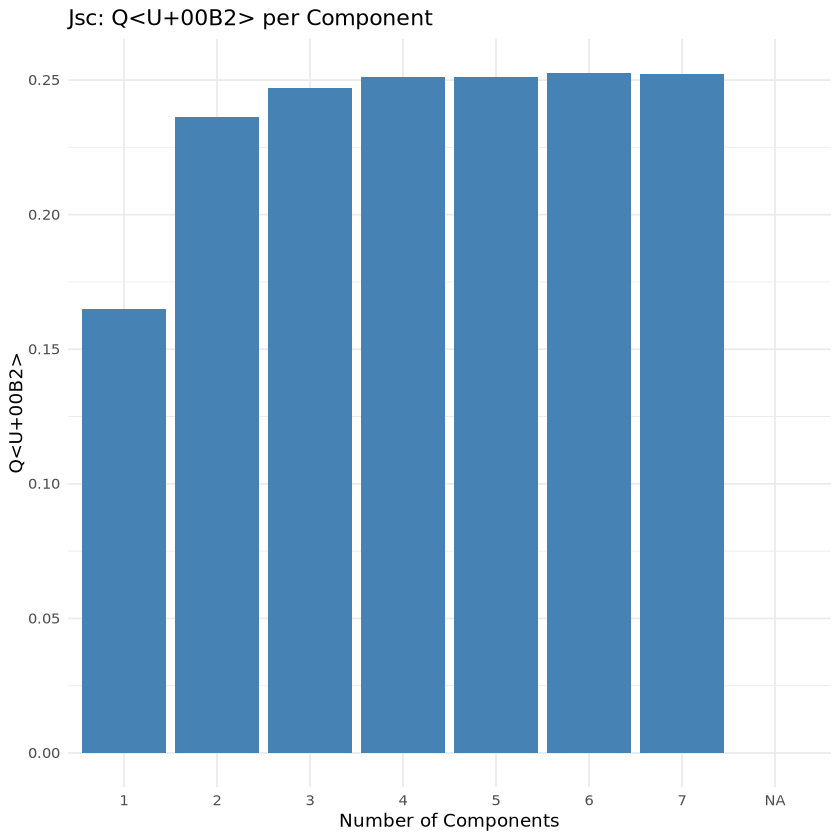


[<U+56DE><U+5E30><U+4FC2><U+6570><U+30E9><U+30F3><U+30AD><U+30F3><U+30B0>]
   MnkDap1M    Egoptp1M Mmonomerp1M     LUMOp1M      PDIp1M     HOMOp1M 
    3.51960     1.13014     0.70347     0.62841     0.37164    -0.39663 
   MwkDap1M 
   -1.68202 

[VIP<U+30B9><U+30B3><U+30A2><U+4E0A><U+4F4D><U+5909><U+6570>]
   MnkDap1M    MwkDap1M Mmonomerp1M      PDIp1M    Egoptp1M     LUMOp1M 
      1.333       0.719       0.503       0.236       0.161       0.083 
    HOMOp1M        <NA>        <NA>        <NA> 
      0.003          NA          NA          NA 


Warning message:
"Removed 3 rows containing missing values or values outside the scale range
(`geom_bar()`)."


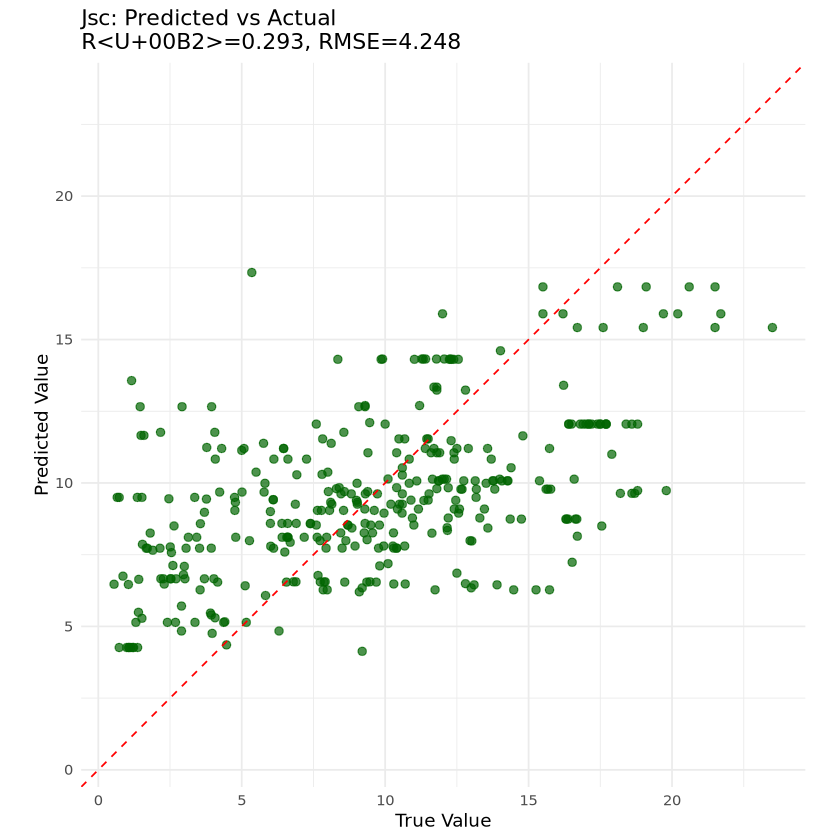

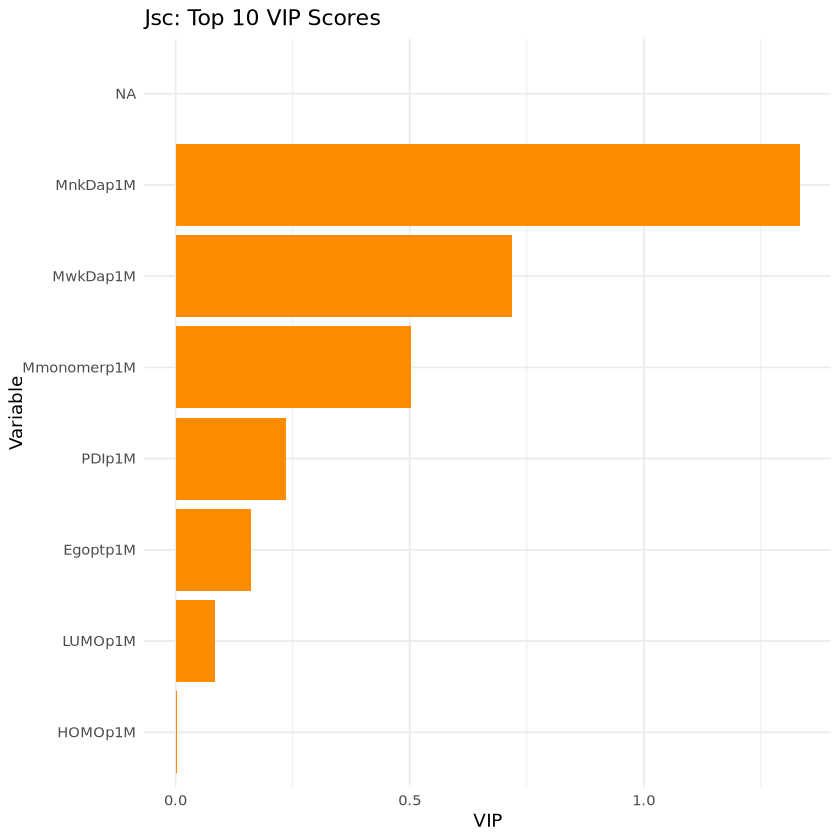


Target: Voc 
R2      = 0.7158 
corALL  = 0.846 
RMSE    = 0.0807 
MAE     = 0.0595 
RPD     = 1.878 


Warning message:
"Removed 13 rows containing missing values or values outside the scale range
(`geom_bar()`)."


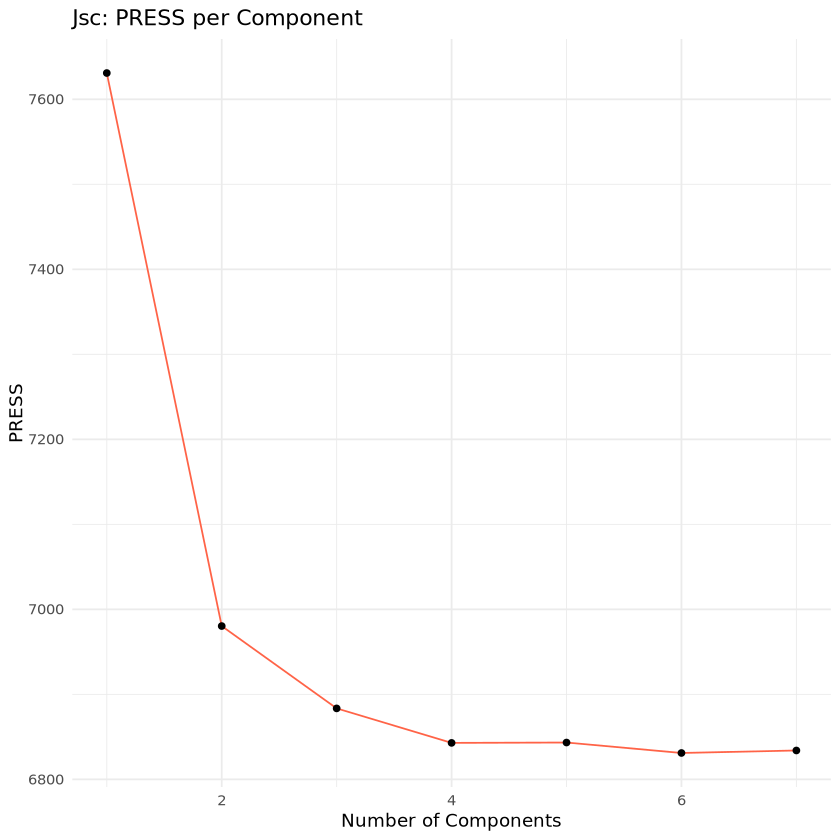

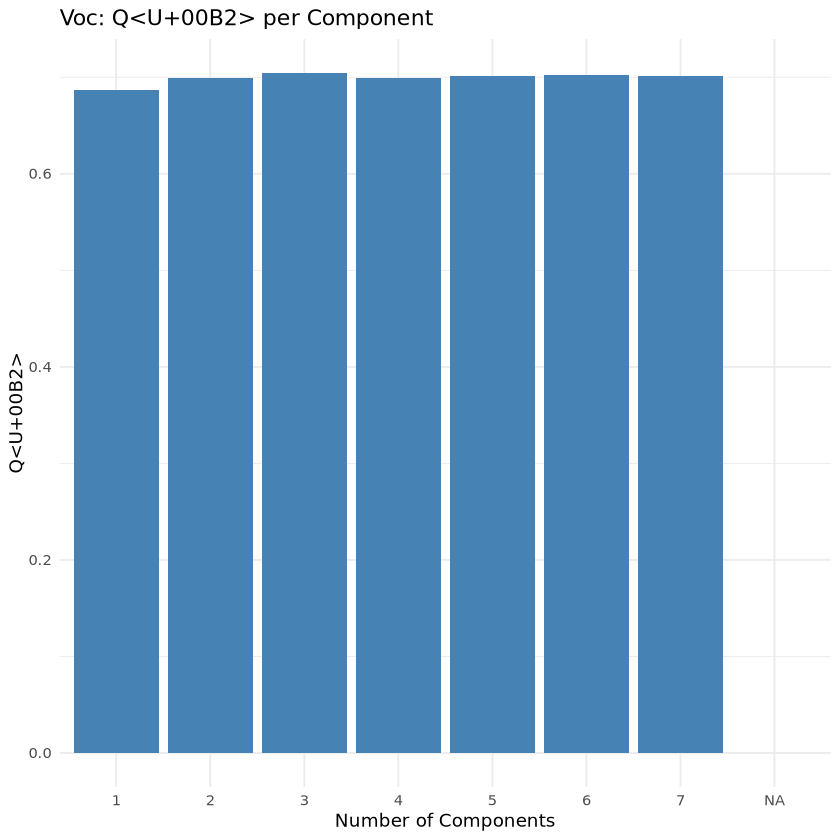


[<U+56DE><U+5E30><U+4FC2><U+6570><U+30E9><U+30F3><U+30AD><U+30F3><U+30B0>]
   Egoptp1M     HOMOp1M Mmonomerp1M    MwkDap1M    MnkDap1M     LUMOp1M 
    0.08287     0.06159     0.02758     0.00944     0.00307    -0.00370 
     PDIp1M 
   -0.00931 

[VIP<U+30B9><U+30B3><U+30A2><U+4E0A><U+4F4D><U+5909><U+6570>]
   Egoptp1M     HOMOp1M     LUMOp1M Mmonomerp1M    MnkDap1M    MwkDap1M 
      1.956       1.588       0.338       0.312       0.117       0.104 
     PDIp1M        <NA>        <NA>        <NA> 
      0.035          NA          NA          NA 


Warning message:
"Removed 3 rows containing missing values or values outside the scale range
(`geom_bar()`)."


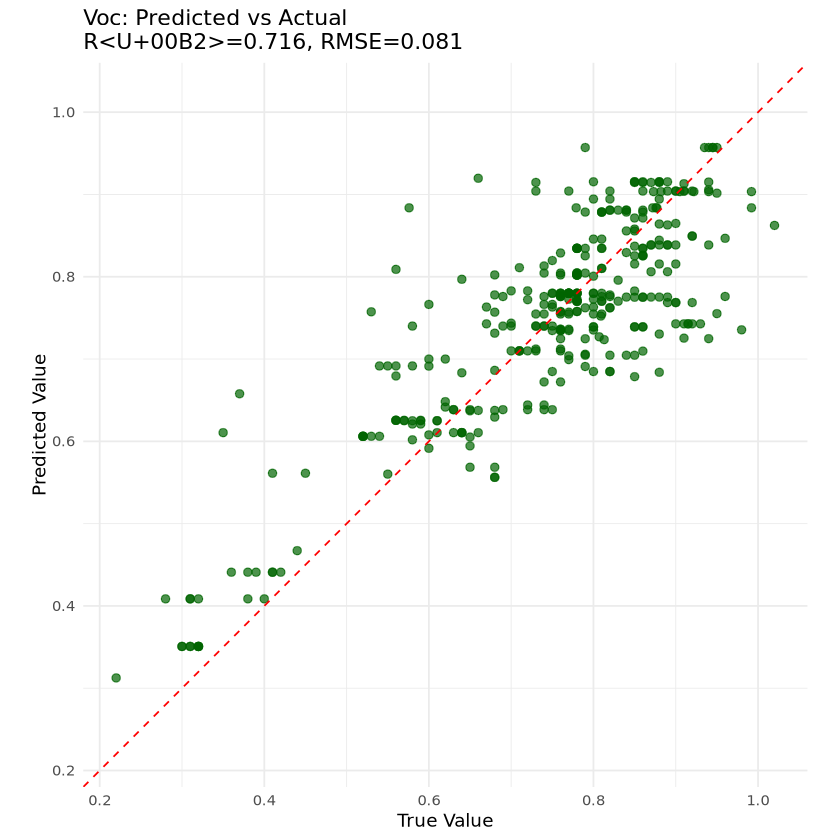

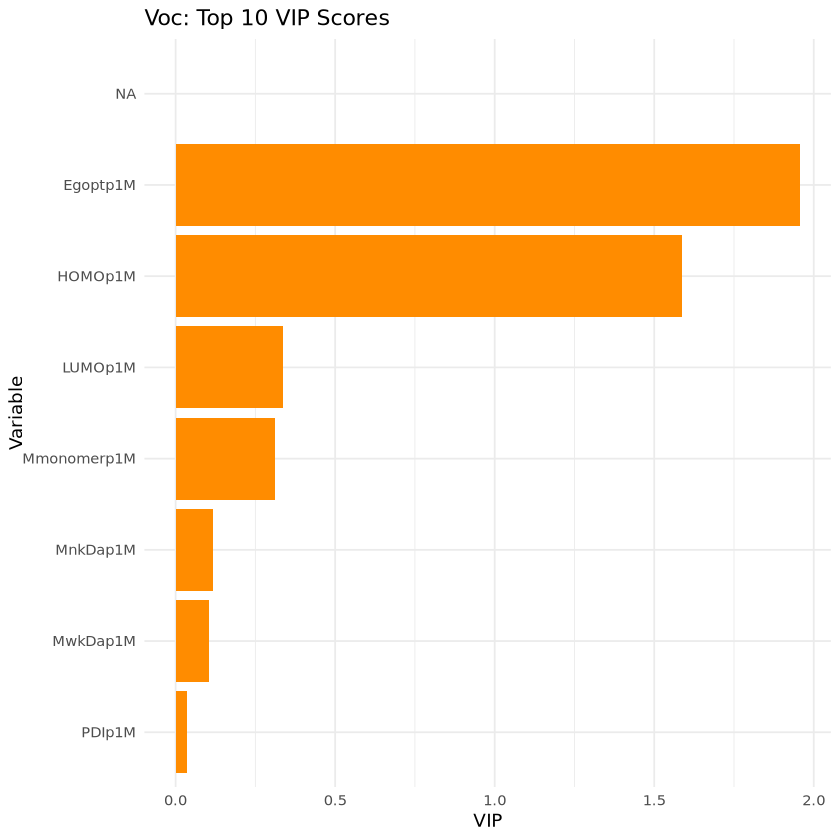


Target: FF 
R2      = 0.1757 
corALL  = 0.4192 
RMSE    = 0.1011 
MAE     = 0.0822 
RPD     = 1.103 


Warning message:
"Removed 13 rows containing missing values or values outside the scale range
(`geom_bar()`)."


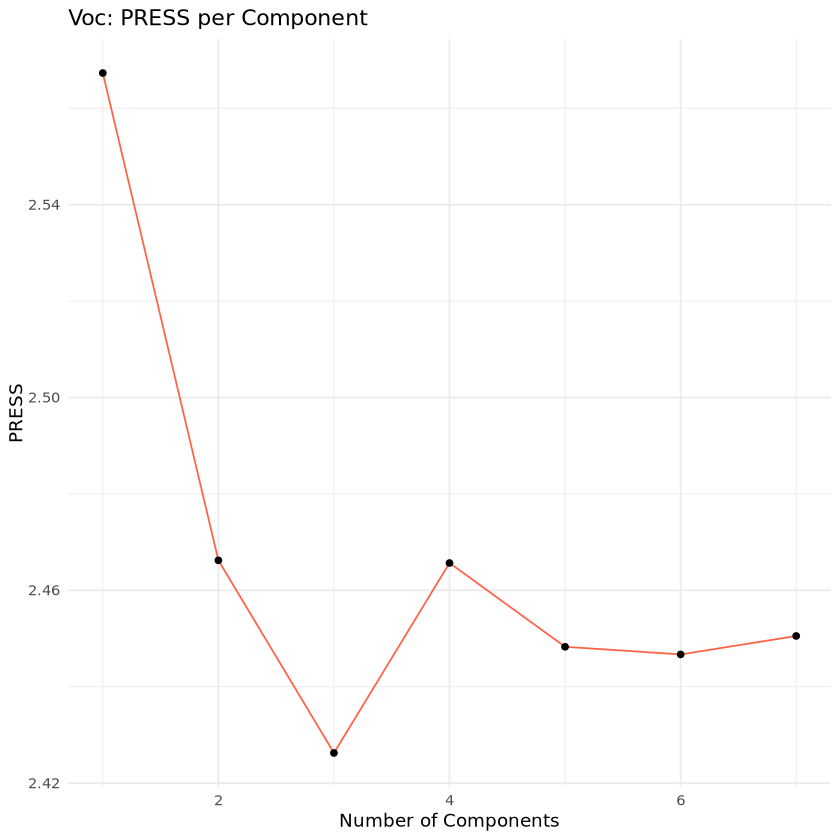

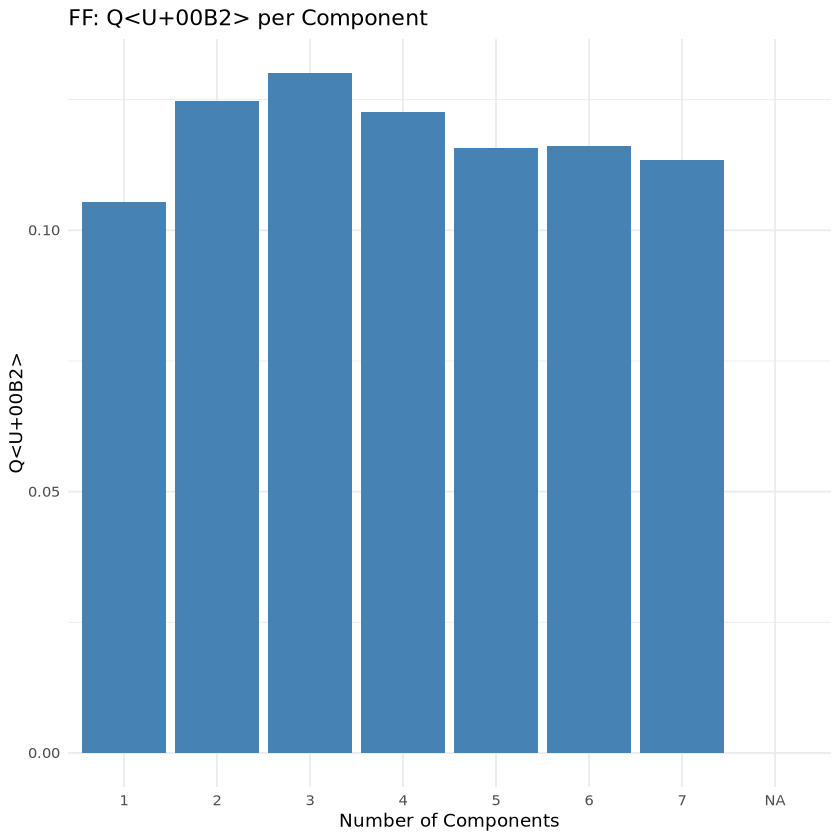


[<U+56DE><U+5E30><U+4FC2><U+6570><U+30E9><U+30F3><U+30AD><U+30F3><U+30B0>]
   MnkDap1M    Egoptp1M Mmonomerp1M     HOMOp1M     LUMOp1M    MwkDap1M 
    0.03730     0.02196     0.01937     0.00781     0.00604     0.00274 
     PDIp1M 
   -0.01483 

[VIP<U+30B9><U+30B3><U+30A2><U+4E0A><U+4F4D><U+5909><U+6570>]
   MnkDap1M    Egoptp1M    MwkDap1M Mmonomerp1M     HOMOp1M      PDIp1M 
      1.346       0.882       0.782       0.718       0.589       0.173 
    LUMOp1M        <NA>        <NA>        <NA> 
      0.090          NA          NA          NA 


Warning message:
"Removed 3 rows containing missing values or values outside the scale range
(`geom_bar()`)."


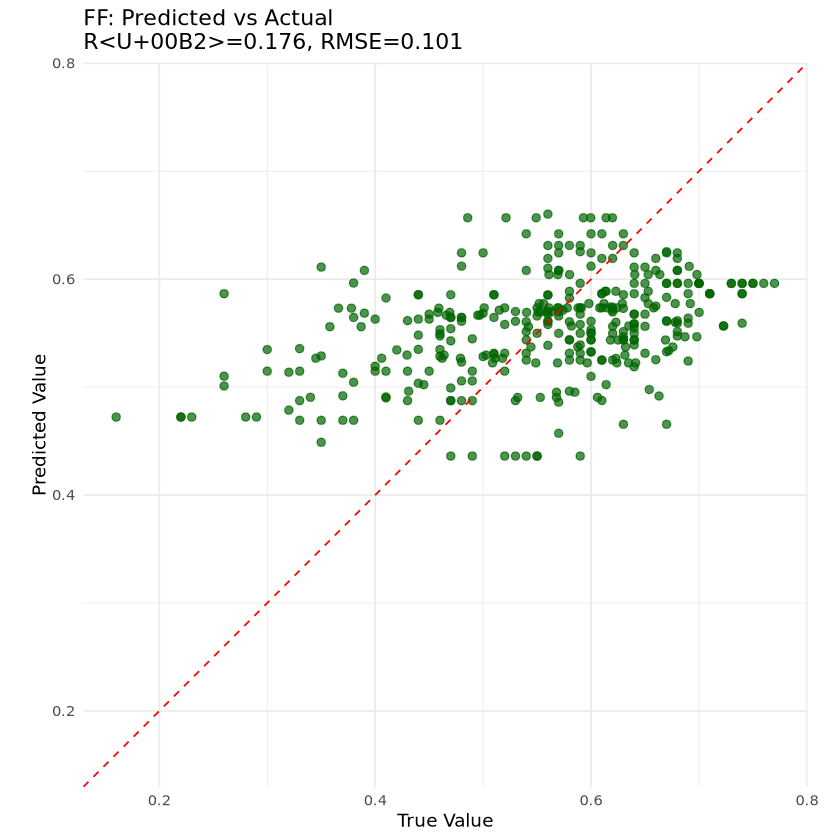

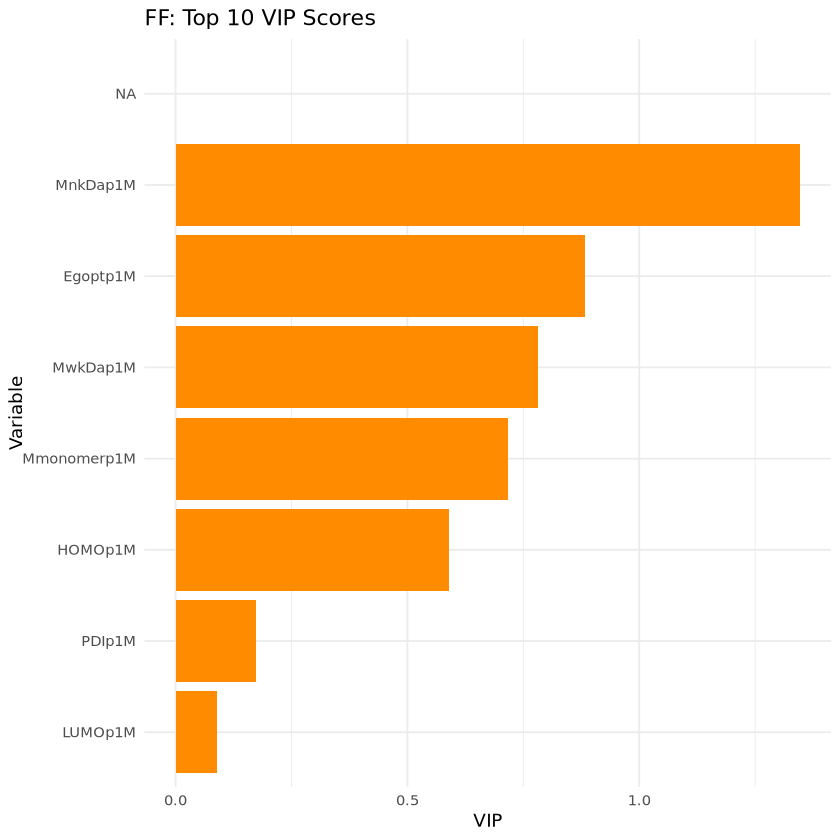


Target: PCEmax 
R2      = 0.2696 
corALL  = 0.5192 
RMSE    = 2.2562 
MAE     = 1.8131 
RPD     = 1.172 


Warning message:
"Removed 13 rows containing missing values or values outside the scale range
(`geom_bar()`)."


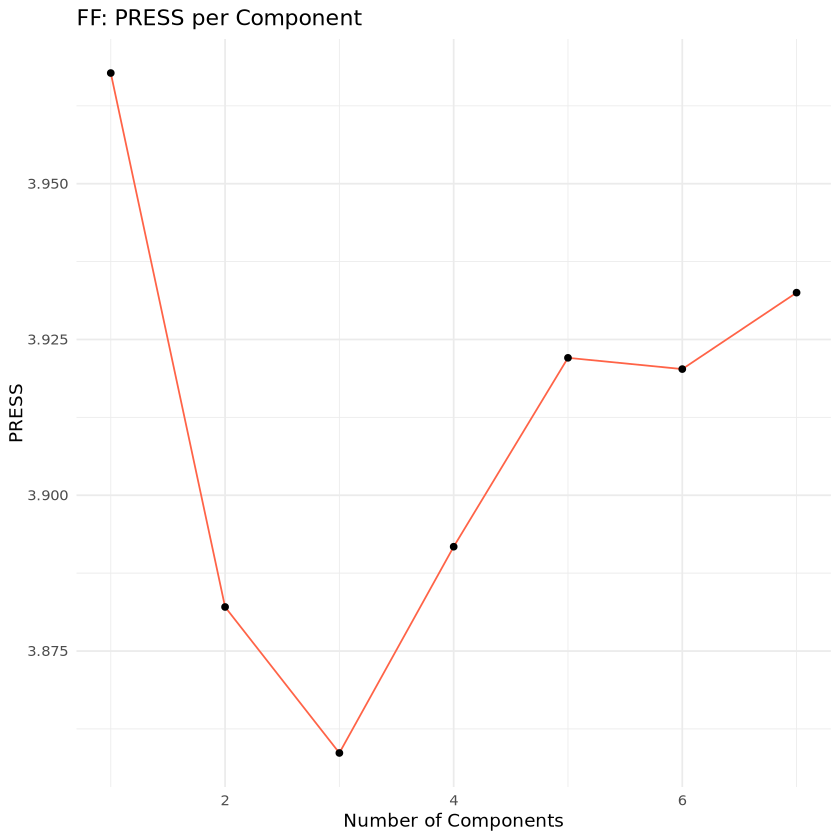

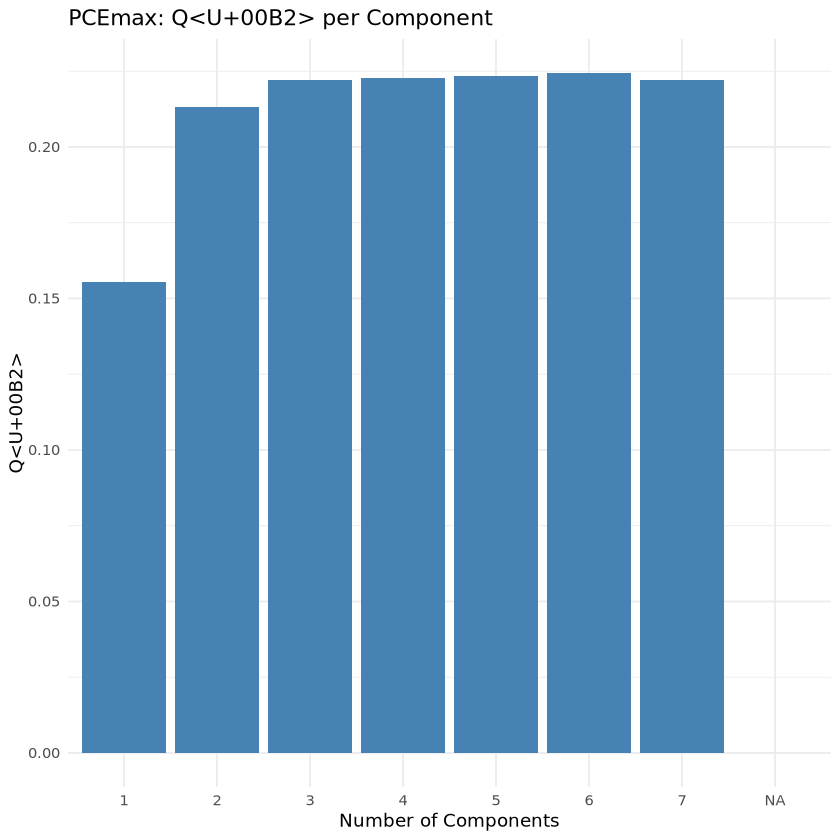


[<U+56DE><U+5E30><U+4FC2><U+6570><U+30E9><U+30F3><U+30AD><U+30F3><U+30B0>]
   MnkDap1M    Egoptp1M     LUMOp1M Mmonomerp1M      PDIp1M     HOMOp1M 
    1.52339     0.98317     0.48752     0.41048     0.15474    -0.17314 
   MwkDap1M 
   -0.70869 

[VIP<U+30B9><U+30B3><U+30A2><U+4E0A><U+4F4D><U+5909><U+6570>]
   MnkDap1M    MwkDap1M    Egoptp1M Mmonomerp1M     HOMOp1M      PDIp1M 
      1.275       0.728       0.658       0.641       0.385       0.276 
    LUMOp1M        <NA>        <NA>        <NA> 
      0.080          NA          NA          NA 


Warning message:
"Removed 3 rows containing missing values or values outside the scale range
(`geom_bar()`)."


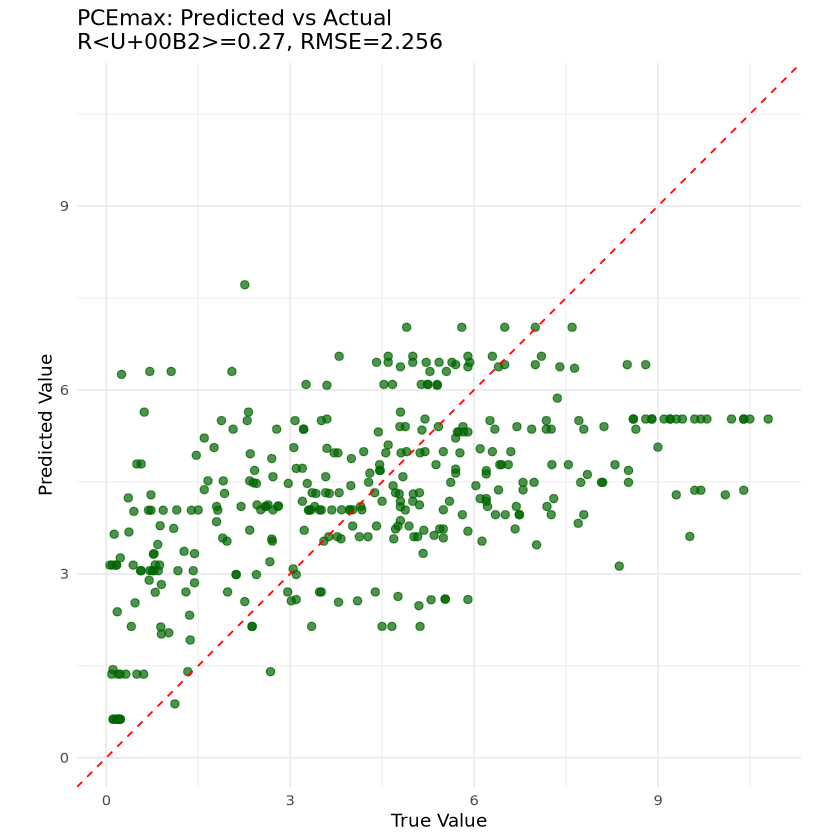

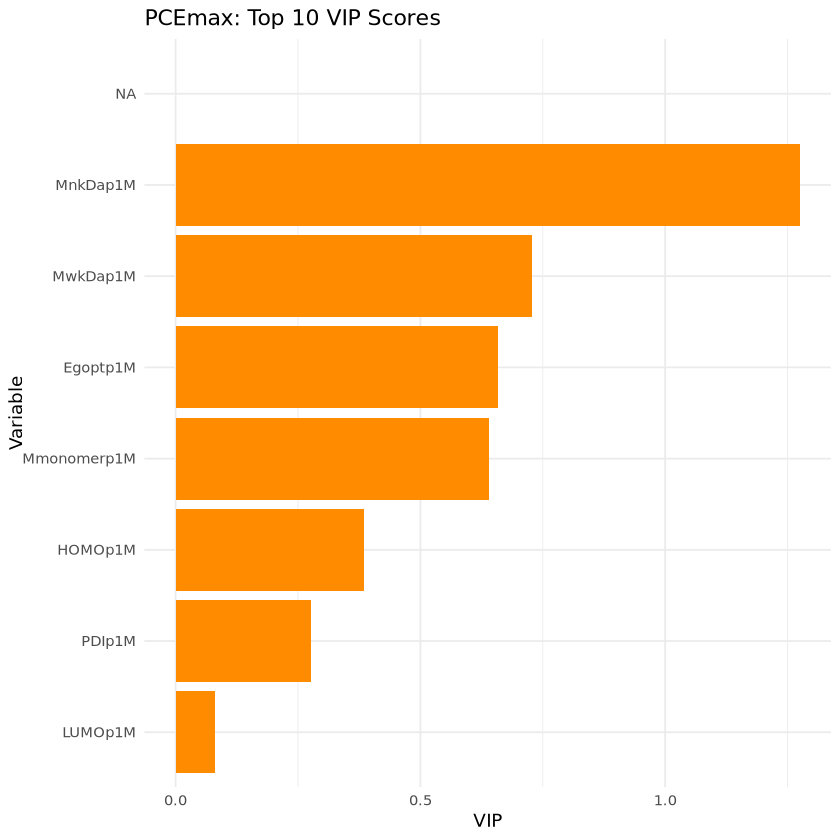

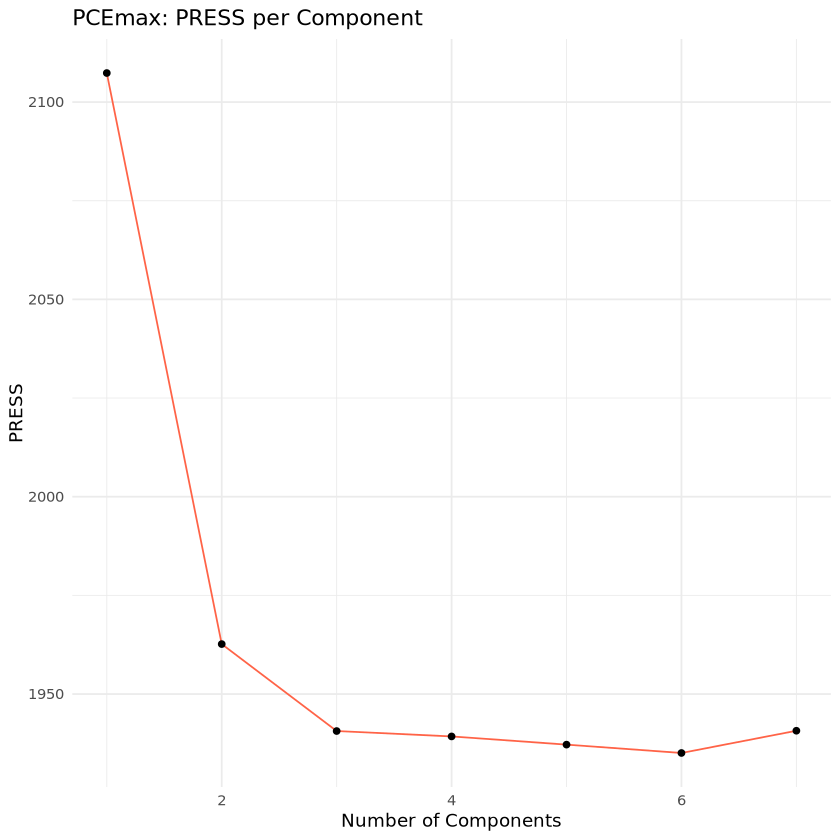

In [16]:
# 必要なパッケージ読み込み
library(pls)
library(plsVarSel)
library(Metrics)
library(ggplot2)

# --- VIPスコアの計算関数（安全版） ---
calc_vip <- function(pls_model, ncomp) {
  max_comp <- min(ncomp, nrow(pls_model$Yloadings))  # 安全性確保
  SS <- pls_model$Yloadings[1:max_comp, , drop = FALSE]^2
  W <- pls_model$loading.weights[, 1:max_comp, drop = FALSE]
  p <- nrow(W)
  Wnorm2 <- colSums(W^2)
  SSY <- sum(SS)

  vip_scores <- numeric(p)
  for (j in 1:p) {
    weight <- 0
    for (a in 1:max_comp) {
      if (Wnorm2[a] == 0) next  # ゼロ除算防止
      weight <- weight + SS[a] * (W[j, a]^2 / Wnorm2[a])
    }
    vip_scores[j] <- sqrt(p * weight / SSY)
  }
  names(vip_scores) <- rownames(W)
  return(vip_scores)
}

# --- データ読み込み ---
ifname <- "n-base-noSMILES.csv"
readData <- read.delim(ifname, header=TRUE, sep=",", row.names=1, as.is=TRUE)
readData2 <- readData[, !sapply(readData, is.character)]

target_y_list <- c("Jsc", "Voc", "FF", "PCEmax")
rmlist <- c("Jsc", "Voc", "FF", "PCEmax", "PCEcal", "PCEdiff", "PCEave")

for (yname in target_y_list) {
  cat("\n=============================\n")
  cat("Target:", yname, "\n")
  cat("=============================\n")

  Y <- readData2[, yname]
  Xnames <- setdiff(colnames(readData2), rmlist)
  X <- readData2[, Xnames]

  Nadata <- is.na(X)
  NNa <- colSums(Nadata)
  XX <- X[, NNa == 0]

  dMerge <- data.frame(Y, XX)
  Nadata <- na.omit(dMerge)
  sdcheck <- apply(Nadata, 2, sd)
  TF <- sdcheck != 0
  ssd <- scale(Nadata[, TF])
  ssd[, 1] <- Nadata[, 1]
  YXdata <- data.frame(ssd)

  set.seed(123)
  result1.pls <- plsr(Y ~ ., data=YXdata, scale=FALSE, validation="CV", segments=10)
  plspress <- result1.pls$validation$PRESS
  ncomponent <- which.min(plspress)

  Ypred1 <- result1.pls$validation$pred[,,ncomponent]
  tss <- sum((YXdata[,1] - mean(YXdata[,1]))^2)
  Q2 <- 1 - plspress / tss
  corCV <- cor(YXdata[,1], Ypred1)

  Ypred2 <- predict(result1.pls, newdata=YXdata, ncomp=ncomponent)
  rss <- sum((YXdata[,1] - Ypred2)^2)
  R2 <- 1 - rss / tss
  CR <- cor(YXdata[,1], Ypred2)
  RMSEval <- rmse(YXdata[,1], Ypred2)
  MAEval <- mae(YXdata[,1], Ypred2)
  sd_Y <- sd(YXdata[,1])
  RPDval <- sd_Y / RMSEval

  cat("R2      =", round(R2, 4), "\n")
  cat("corALL  =", round(CR, 4), "\n")
  cat("RMSE    =", round(RMSEval, 4), "\n")
  cat("MAE     =", round(MAEval, 4), "\n")
  cat("RPD     =", round(RPDval, 3), "\n")

  # Q2バーグラフ
  df_q2 <- na.omit(data.frame(Component = seq_along(Q2), Q2 = as.numeric(Q2)))
  print(
    ggplot(df_q2[1:20, ], aes(x = factor(Component), y = Q2)) +
      geom_bar(stat = "identity", fill = "steelblue") +
      labs(title = paste0(yname, ": Q² per Component"),
           x = "Number of Components", y = "Q²") +
      theme_minimal()
  )

  # 予測 vs 実測プロット
  df_pred <- data.frame(True = YXdata[,1], Predicted = as.vector(Ypred2))
  lims <- range(c(df_pred$True, df_pred$Predicted), na.rm = TRUE)
  print(
    ggplot(df_pred, aes(x = True, y = Predicted)) +
      geom_point(color = "darkgreen", alpha = 0.7, size = 2) +
      geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "red") +
      labs(title = paste0(yname, ": Predicted vs Actual\nR²=", round(R2, 3), ", RMSE=", round(RMSEval, 3)),
           x = "True Value", y = "Predicted Value") +
      coord_fixed(ratio = 1, xlim = lims, ylim = lims) +
      theme_minimal()
  )

  # 回帰係数
  coefs <- coefficients(result1.pls, ncomp=ncomponent)[,1,1]
  sorted_coefs <- sort(coefs, decreasing=TRUE)
  cat("\n[回帰係数ランキング]\n")
  print(round(sorted_coefs, 5))

  # VIPスコア
  vip_scores <- calc_vip(result1.pls, ncomponent)
  vip_sorted <- sort(vip_scores, decreasing = TRUE)
  cat("\n[VIPスコア上位変数]\n")
  print(round(vip_sorted[1:10], 3))

  df_vip <- data.frame(Variable = names(vip_sorted[1:10]), VIP = vip_sorted[1:10])
  df_vip$Variable <- factor(df_vip$Variable, levels = rev(df_vip$Variable))
  print(
    ggplot(df_vip, aes(x = Variable, y = VIP)) +
      geom_bar(stat = "identity", fill = "darkorange") +
      coord_flip() +
      labs(title = paste0(yname, ": Top 10 VIP Scores")) +
      theme_minimal()
  )

  # PRESSプロット
  press_df <- data.frame(Component = seq_along(plspress), PRESS = as.numeric(plspress))
  print(
    ggplot(press_df, aes(x = Component, y = PRESS)) +
      geom_line(color = "tomato") +
      geom_point() +
      theme_minimal() +
      labs(title = paste0(yname, ": PRESS per Component"),
           x = "Number of Components", y = "PRESS")
  )
} 
